In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from plot import make_theme, plot_image, interp

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

In [3]:
def transition(x, A=1., t0=70., beta=1., c=0.):
    y = A * (t0 - x) ** beta + c
    y[x>=t0] = c
    return y

def fit_peak(x, y, x0=0, bg=None, fraction=False):
    model = lmfit.models.ConstantModel(prefix='bg_') + lmfit.models.PseudoVoigtModel(prefix='p_')
    params = model.make_params()
    if bg is None:
        params['bg_c'].set(value=0.1, min=0., max=1e3)
    else:
        params['bg_c'].set(value=bg, vary=False)
    params['p_sigma'].set(value=0.01, min=1e-5, max=0.1)
    params['p_amplitude'].set(value=100., min=1e-3, max=1e5)
    params['p_center'].set(value=x0, min=x0-0.02, max=x0+0.02)
    params['p_fraction'].set(value=0., min=0., max=1., vary=fraction) # fraction=0 for Gaussian
    result = model.fit(y, x=x, params=params)
    print(result.message)
    return result, model.eval(params=result.params, x=x)

# Main text figure

Fit succeeded.
{'A': 0.29075685711935345, 't0': 72.6727271209897, 'beta': 0.8068892884967879, 'c': 0.012788694690614513}


C:\Users\yshen\AppData\Local\Temp\ipykernel_10592\2874292435.py:2: RuntimeWarning: invalid value encountered in power
  y = A * (t0 - x) ** beta + c


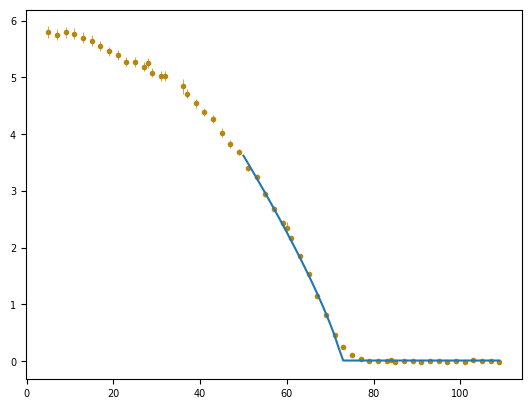

In [4]:
model = lmfit.Model(transition)
params = model.make_params()
params['t0'].set(value=70., min=60., max=90., vary=True)
data = np.loadtxt('../corelli/Order_mag_warming_fitTdep.dat')
Tmin = 50.
choose = data[:,0]>=Tmin
result = model.fit(data[choose,1], x=data[choose,0], weights=1/data[choose,2], params=params)
print(result.message)
print(result.best_values)

fig, ax = plt.subplots()
ax.errorbar(data[:,0], data[:,1], data[:,2], fmt='o', elinewidth=0.5, ls='none', ms=3, color='darkgoldenrod', zorder=0)
# ax.plot(data[choose,0], result.best_fit)
x_fit = np.arange(Tmin,np.max(data[:,0])+1e-8,1.)
y_fit = transition(x_fit, A=result.best_values['A'], t0=result.best_values['t0'], c=result.best_values['c'], beta=result.best_values['beta'])
ax.plot(x_fit, y_fit)

order_param = dict(x=x_fit, y=y_fit)

In [5]:
result.params

name,value,standard error,relative error,initial value,min,max,vary
A,0.29075686,0.09578158,(32.94%),1.0,-inf,inf,True
t0,72.6727271,0.79447897,(1.09%),70.0,60.0000000,90.0000000,True
beta,0.80688929,0.10726812,(13.29%),1.0,-inf,inf,True
c,0.01278869,0.00843366,(65.95%),0.0,-inf,inf,True


In [5]:
def plot_HK0_plane(axs):
    ## 250 K
    ax = axs[0]
    data = dict(np.load('../corelli/HEPS3_HK0_250K.npz'))
    choosex = np.abs(data['Hrlu'])<=1.9
    choosey = np.abs(data['Krlu'])<=2.9
    plot_image(data['I'][choosey,:][:,choosex], x=data['Hrlu'][choosex], y=data['Krlu'][choosey], ax=ax, cmap=cmap, vmin=0., vmax=1)
    ## config
    ax.set_aspect(data['aspect'])
    ax.tick_params(labelbottom=False)
    ax.set_title('$T$=250 K', fontsize=7)
    plot_label(ax, 'a', x=0, y=1.06)
    ## 6 K
    ax = axs[1]
    data = dict(np.load('../corelli/HEPS3_HK0_006K.npz'))
    choosex = np.abs(data['Hrlu'])<=1.9
    choosey = np.abs(data['Krlu'])<=2.9
    plot_image(data['I'][choosey,:][:,choosex], x=data['Hrlu'][choosex], y=data['Krlu'][choosey], ax=ax, cmap=cmap, vmin=0., vmax=1)
    ## config
    ax.set_aspect(data['aspect'])
    ax.set_title('$T$=6 K', fontsize=7)
    plot_label(ax, 'b', x=0, y=1.06)
    
    for ax in axs:
        xys = np.vstack([[1.,1.], [0.,2.], [-1.,1.], [-1.,-1.], [0.,-2.], [1.,-1.]])
        ax.plot(xys[:,0], xys[:,1], 'o', color='k', mfc='none', mew=0.5, ms=10)
        make_theme(ax, ticklength=4)
        ax.set_xlim(-1.8,1.8)
        ax.set_xticks(np.arange(-1.,1.01,1.))
        ax.set_ylim(-2.8,2.8)
        ax.set_yticks(np.arange(-2.,2.01,1.))
        ax.set_ylabel('(0, $K$, 0) (r.l.u.)')
    axs[0].text(0.3, 2., 'nuclear', fontsize=7, horizontalalignment='left', verticalalignment='center')
    axs[1].set_xlabel('($H$, 0, 0) (r.l.u.)')

def plot_0KL_plane(axs, cax):
    ## 250 K
    ax = axs[0]
    data = dict(np.load('../corelli/HEPS3_0KL_250K.npz'))
    choosex = np.abs(data['Krlu'])<=1.6
    choosey = np.abs(data['Lrlu'])<=1.6
    _, art = plot_image(data['I'][choosey,:][:,choosex], x=data['Krlu'][choosex], y=data['Lrlu'][choosey], ax=ax, cmap=cmap, vmin=0., vmax=1)
    ## config
    ax.set_aspect(data['aspect'])
    ax.tick_params(labelbottom=False)
    ax.set_title('$T$=250 K', fontsize=7)
    plot_label(ax, 'c', x=0, y=1.06)
    ## 6 K
    ax = axs2[1]
    data = dict(np.load('../corelli/HEPS3_0KL_006K.npz'))
    choosex = np.abs(data['Krlu'])<=1.6
    choosey = np.abs(data['Lrlu'])<=1.6
    plot_image(data['I'][choosey,:][:,choosex], x=data['Krlu'][choosex], y=data['Lrlu'][choosey], ax=ax, cmap=cmap, vmin=0., vmax=1)
    ## config
    ax.set_aspect(data['aspect'])
    ax.set_title('$T$=6 K', fontsize=7)
    plot_label(ax, 'd', x=0, y=1.06)
    
    for ax in axs:
        xys = np.vstack([[0.,1.], [0.,-1.]])
        ax.plot(xys[:,0], xys[:,1], 'o', color='k', mfc='none', mew=0.5, ms=10)
        make_theme(ax, ticklength=4)
        ax.set_xlim(-1.5,1.5)
        ax.set_xticks(np.arange(-1.,1.01,1.))
        ax.set_ylim(-1.5,1.5)
        ax.set_yticks(np.arange(-1.,1.01,1.))
        ax.set_ylabel('(0, 0, $L$) (r.l.u.)')
    axs[0].text(0., 0.6, 'nuclear', fontsize=7, horizontalalignment='center', verticalalignment='center')
    axs[1].set_xlabel('(0, $K$, 0) (r.l.u.)')
    
    # colorbar
    cbar = plt.colorbar(art, cax=cax)
    cbar.set_label('Intensity (arb. units)')
    cbar.outline.set_linewidth(0.5)
    cbar.ax.tick_params(width=0.5, length=0.)
    cbar.set_ticks([0.,1])

def plot_Hcuts(ax, color):
    alldata = dict(np.load('../corelli/HEPS3_HKL_006K.npz'))
    ## nuclear@6 K
    dHKL = [0.5,0.04,0.05]
    HKL = [0.,2.,0.]
    chooseH = np.abs(alldata['Hrlu']-HKL[0])<=dHKL[0]
    chooseK = np.abs(alldata['Krlu']-HKL[1])<=dHKL[1]
    chooseL = np.abs(alldata['Lrlu']-HKL[2])<=dHKL[2]
    x = alldata['Hrlu'][chooseH]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,1))
    choose = np.abs(x-HKL[0])>=0.2
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=0., fraction=False)
    print('Nuclear peak width along H: {}'.format(result.params['p_fwhm']))
    cut1 = dict(x=x, y=y, y_fit=y_fit, result=result)
    ## magnetic@6 K
    HKL = [0.,1.,0.]
    chooseH = np.abs(alldata['Hrlu']-HKL[0])<=dHKL[0]
    chooseK = np.abs(alldata['Krlu']-HKL[1])<=dHKL[1]
    chooseL = np.abs(alldata['Lrlu']-HKL[2])<=dHKL[2]
    x = alldata['Hrlu'][chooseH]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,1))
    choose = np.abs(x-HKL[0])>=0.2
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=0., fraction=False)
    print('Magnetic peak width along H: {}'.format(result.params['p_fwhm']))
    cut2 = dict(x=x, y=y, y_fit=y_fit, result=result)
    ## magnetic@90 K
    alldata = dict(np.load('../corelli/HEPS3_HKL_090K.npz'))
    x = alldata['Hrlu'][chooseH]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,1))
    choose = np.abs(x-HKL[0])>=0.2
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=0., fraction=False)
    cut3 = dict(x=x, y=y, y_fit=y_fit, result=result)
    ## magnetic@250 K
    alldata = dict(np.load('../corelli/HEPS3_HKL_250K.npz'))
    x = alldata['Hrlu'][chooseH]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,1))
    cut4 = dict(x=x, y=y)
    ## plot
    ax.plot(np.nan, np.nan, 'none', lw=0, color='goldenrod', ms=3, mfc='w', mew=0.5, label='(0, 1, 0)')
    ax.plot(cut4['x'], cut4['y'], 'D', color='goldenrod', ms=3, mfc='w', mew=0.5, label='250 K', zorder=1)
    ax.plot(cut2['x'], cut2['y'], 'o', color='darkgoldenrod', ms=3, label='6 K', zorder=10)
    ax.plot(cut2['x'], cut2['y_fit'], '-', lw=0.5, color='darkgoldenrod', zorder=11)
    ax.plot(np.nan, np.nan, 'none', lw=0, color='goldenrod', ms=3, mfc='w', mew=0.5, label='(0, 2, 0)')
    ax.plot(cut1['x'], cut1['y'], 's', color=color, ms=3, label='6 K', zorder=5)
    ax.plot(cut1['x'], cut1['y_fit'], '-', lw=0.5, color=color, zorder=6)
    ## config
    make_theme(ax, ticklength=4)
    ax.set_yscale('log')
    ax.legend(frameon=False, loc='upper right', markerscale=1.5, handletextpad=0, labelspacing=0.2, columnspacing=0)
    ax.set_xlim(-0.3,0.3)
    # ax.set_xticks(np.arange(-1.,1.01,1.))
    ax.set_ylim(0.06,40)
    ax.set_xlabel('($H$, 1, 0) (r.l.u.)')
    ax.set_ylabel('Intensity (arb. units)')
    plot_label(ax, 'e', x=0.05, y=0.8)

def plot_Kcuts(ax, color):
    alldata = dict(np.load('../corelli/HEPS3_HKL_006K.npz'))
    ## nuclear@6 K
    dHKL = [0.02,0.5,0.05]
    HKL = [0.,2.,0.]
    chooseH = np.abs(alldata['Hrlu']-HKL[0])<=dHKL[0]
    chooseK = np.abs(alldata['Krlu']-HKL[1])<=dHKL[1]
    chooseL = np.abs(alldata['Lrlu']-HKL[2])<=dHKL[2]
    x = alldata['Krlu'][chooseK]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,2))
    choose = np.abs(x-HKL[1])>=0.2
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=2., fraction=False)
    print('Nuclear peak width along K: {}'.format(result.params['p_fwhm']))
    cut1 = dict(x=x, y=y, y_fit=y_fit, result=result)
    ## magnetic@6 K
    HKL = [0.,1.,0.]
    chooseH = np.abs(alldata['Hrlu']-HKL[0])<=dHKL[0]
    chooseK = np.abs(alldata['Krlu']-HKL[1])<=dHKL[1]
    chooseL = np.abs(alldata['Lrlu']-HKL[2])<=dHKL[2]
    x = alldata['Krlu'][chooseK]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,2))
    choose = np.abs(x-HKL[1])>=0.2
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=1., fraction=False)
    print('Magnetic peak width along K: {}'.format(result.params['p_fwhm']))
    cut2 = dict(x=x, y=y, y_fit=y_fit, result=result)
    ## magnetic@90 K
    alldata = dict(np.load('../corelli/HEPS3_HKL_090K.npz'))
    x = alldata['Krlu'][chooseK]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,2))
    choose = np.abs(x-HKL[1])>=0.2
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=1., fraction=False)
    cut3 = dict(x=x, y=y, y_fit=y_fit, result=result)
    ## magnetic@250 K
    alldata = dict(np.load('../corelli/HEPS3_HKL_250K.npz'))
    x = alldata['Krlu'][chooseK]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,2))
    cut4 = dict(x=x, y=y)
    ## plot
    ax.plot(np.nan, np.nan, 'none', lw=0, color='goldenrod', ms=3, mfc='w', mew=0.5, label='(0, 1, 0)')
    ax.plot(cut4['x'], cut4['y'], 'D', color='goldenrod', ms=3, mfc='w', mew=0.5, label='250 K', zorder=1)
    ax.plot(cut2['x'], cut2['y'], 'o', color='darkgoldenrod', ms=3, label='6 K', zorder=10)
    ax.plot(cut2['x'], cut2['y_fit'], '-', lw=0.5, color='darkgoldenrod', zorder=11)
    newax = ax.twiny()
    newax.plot(np.nan, np.nan, 'none', lw=0, color='goldenrod', ms=3, mfc='w', mew=0.5, label='(0, 2, 0)')
    newax.plot(cut1['x'], cut1['y'], 's', color=color, ms=3, label='6 K', zorder=5)
    newax.plot(cut1['x'], cut1['y_fit'], '-', lw=0.5, color=color, zorder=6)
    ## config
    ### main ax
    make_theme(ax, ticklength=4)
    ax.set_yscale('log')
    ax.legend(frameon=False, loc='upper right', markerscale=1.5, handletextpad=0, labelspacing=0.2, columnspacing=0)
    ax.tick_params(axis='x', color='darkgoldenrod', which='both', labelcolor='darkgoldenrod')
    ax.spines['bottom'].set_color('darkgoldenrod')
    ax.tick_params(top=False, labeltop=False, which='both')
    ax.spines['top'].set_visible(False)
    ax.set_xlim(0.7,1.3)
    ax.set_xticks(np.arange(0.7,1.31,0.1))
    ax.set_ylim(0.06,40)
    ax.set_xlabel('(0, $K$, 0) (r.l.u.)')
    plot_label(ax, 'f', x=0.05, y=0.8)
    ### twin ax
    make_theme(newax, ticklength=4, logy=True)
    newax.legend(frameon=False, loc='upper left', markerscale=1.5, handletextpad=0, labelspacing=0.2, columnspacing=0)
    newax.tick_params(axis='x', color=color, which='both', labelcolor=color)
    newax.spines['top'].set_color(color)
    newax.tick_params(bottom=False, left=False, right=False, labelbottom=False, labelleft=False, labelright=False, which='both')
    for loc in ['bottom','left','right']:
        newax.spines[loc].set_visible(False)
    newax.set_xlim(1.7,2.3)
    newax.set_xticks(np.arange(1.7,2.31,0.1))
    newax.set_ylim(0.06,40)

def plot_Ldep(ax, color, T90=True):
    ## 250 K
    alldata = dict(np.load('../corelli/HEPS3_HKL_250K.npz'))
    dHKL = [0.02,0.04,1.]
    HKL = [0.,1.,0.5]
    chooseH = np.abs(alldata['Hrlu']-HKL[0])<=dHKL[0]
    chooseK = np.abs(alldata['Krlu']-HKL[1])<=dHKL[1]
    chooseL = np.abs(alldata['Lrlu']-HKL[2])<=dHKL[2]
    x = alldata['Lrlu'][chooseL]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2))
    cut1 = dict(x=x, y=y)
    choose = np.logical_and(x>=-0.5, y<=1.5)
    bg = np.mean(y[choose])
    ## 90 K
    alldata = dict(np.load('../corelli/HEPS3_HKL_090K.npz'))
    x = alldata['Lrlu'][chooseL]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2))
    cut2 = dict(x=x, y=y)
    ## 6 K
    alldata = dict(np.load('../corelli/HEPS3_HKL_006K.npz'))
    x = alldata['Lrlu'][chooseL]
    y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2))
    cut3 = dict(x=x, y=y)
    ### fit L=0
    model = lmfit.models.GaussianModel()
    params = model.make_params()
    params['sigma'].set(value=0.01, min=1e-5, max=0.1)
    params['amplitude'].set(value=100., min=1e-3, max=1e5)
    params['center'].set(value=0., min=-0.02, max=0.02)
    choose = np.logical_and(x>=-0.022, x<=0.022)
    result = model.fit(y[choose]-bg, x=x[choose], params=params)
    x_fit = np.arange(-0.1,0.1001,0.001)
    # x_fit = x[choose]
    y_fit = model.eval(params=result.params, x=x_fit)
    fit_31 = dict(x=x_fit, y=y_fit)
    ### fit L=1
    params['center'].set(value=1., min=1-0.02, max=1.02)
    choose = np.logical_and(x>=1-0.022, x<=1.022)
    result = model.fit(y[choose]-bg, x=x[choose], params=params)
    x_fit = np.arange(1-0.1,1.1001,0.001)
    # x_fit = x[choose]
    y_fit = model.eval(params=result.params, x=x_fit)
    fit_32 = dict(x=x_fit, y=y_fit)
    ## plot
    if T90:
        ### 250 K
        ax.plot(cut1['x'], cut1['y'], 'o', ms=3, color='goldenrod', mfc='w', mew=0.5, zorder=-1, label='250 K')
        ### 90 K
        ax.plot(cut2['x'], cut2['y'], 'o', ms=3, color=color, zorder=-2, label='90 K')
        # ax.plot(cut2['x'], cut2['y'], '-', color='goldenrod', lw=2, zorder=-1, label='90 K')
    else:
        ### 250 K
        ax.plot(cut1['x'], cut1['y'], 'D', ms=3, color='goldenrod', mfc='w', mew=0.5, zorder=-2, label='250 K')
    ### 6 K
    ax.plot(cut3['x'], cut3['y'], 'o', ms=3, color='goldenrod', mew=0.5, zorder=0, label='6 K')
    choose = fit_31['y']>=1e-3
    ax.fill_between(fit_31['x'][choose], fit_31['y'][choose]+bg, bg, lw=0., color='goldenrod', zorder=-10, alpha=0.5)
    choose = fit_32['y']>=1e-3
    ax.fill_between(fit_32['x'][choose], fit_32['y'][choose]+bg, bg, lw=0., color='goldenrod', zorder=-10, alpha=0.5)
    ## config
    make_theme(ax, ticklength=4)
    ax.axhline(y=bg, lw=0.5, ls='--', color='k', zorder=2)
    ax.legend(loc='upper right', frameon=False, markerscale=1.5, handletextpad=0, labelspacing=3, columnspacing=0.5, ncol=3)
    ax.text(0.5, 0.65, '3D signals', color='k', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.text(0.5, 0.45, '2D signals', color='k', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.arrow(0.38, 0.65, -0.05, 0., head_width=0.03, head_length=0.03, color='k', lw=0.5, transform=ax.transAxes)
    ax.arrow(0.62, 0.65, 0.05, -0.01, head_width=0.03, head_length=0.03, color='k', lw=0.5, transform=ax.transAxes)
    ax.arrow(0.38, 0.45, -0.015, -0.015, head_width=0.03, head_length=0.03, color='k', lw=0.5, transform=ax.transAxes)
    ax.arrow(0.62, 0.45, 0.05, -0.08, head_width=0.03, head_length=0.03, color='k', lw=0.5, transform=ax.transAxes)
    ax.set_yscale('log')
    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks(np.arange(-0.5,1.51,0.5))
    ax.set_xlabel('(0, 1, $L$) (r.l.u.)')
    ax.set_ylim(0.1,100.)
    ax.set_ylabel('Intensity (arb. units)')
    plot_label(ax, 'g', x=0, y=1.05)

def plot_Tdep(ax):
    ## data 3D
    data = np.loadtxt('../corelli/Order_mag_warming_fitTdep.dat')
    ax.errorbar(data[:,0], data[:,1], data[:,2], fmt='o', elinewidth=0.5, ls='none', ms=3, color='goldenrod', mew=0.5, mfc='w', zorder=0, label='3D: $Q=(0, 1, 1)$')
    ## fit 3D
    model = lmfit.Model(transition)
    params = model.make_params()
    params['t0'].set(value=70., min=60., max=90., vary=True)
    Tmin = 50.
    choose = data[:,0]>=Tmin
    result = model.fit(data[choose,1], x=data[choose,0], weights=1/data[choose,2], params=params)
    x_fit = np.arange(Tmin,np.max(data[:,0])+1e-8,1.)
    y_fit = transition(x_fit, A=result.best_values['A'], t0=result.best_values['t0'], c=result.best_values['c'], beta=result.best_values['beta'])
    ax.plot(x_fit, y_fit, '-', lw=1, color='darkgoldenrod', zorder=2)
    ## data 2D
    data = np.loadtxt('../corelli/Order_mag_warming_fit.dat')
    normf = 1/2
    ax.errorbar(data[:,0], data[:,1]*normf, data[:,2]*normf, fmt='D', color='gray', elinewidth=0.5, ls='none', ms=3, label='$\\times${}, 2D: $Q=(1/2, 1/2, 0)$'.format(normf), zorder=-10)
    ## config
    make_theme(ax, ticklength=4)
    ax.legend(frameon=False, loc='lower left')
    ax.set_xlim(0, 110)
    ax.set_xticks(np.arange(0.,110.1,20))
    ax.set_xlabel('Temperature (K)')
    ax.set_ylim(-1,7)
    ax.set_yticks(np.arange(0.,6.1,2.))
    ax.set_ylabel('Integrated intensity (arb. units)')
    ax.axhline(y=0., lw=0.5, color='k', ls='--', zorder=1)
    ax.arrow(73, 3, 0., -0.6, head_width=3, head_length=0.5, color='k', lw=0.5)
    ax.text(65, 3.5, r'$T_N\approx73$ K', color='k')
    plot_label(ax, 'h', x=0, y=1.05)

Fit succeeded.
Nuclear peak width along H: <Parameter 'p_fwhm', value=0.05389198146779 +/- 0.000636, bounds=[-inf:inf], expr='2.0000000*p_sigma'>
Fit succeeded.
Magnetic peak width along H: <Parameter 'p_fwhm', value=0.04958868928763701 +/- 0.000475, bounds=[-inf:inf], expr='2.0000000*p_sigma'>
Fit succeeded.
Fit succeeded.
Nuclear peak width along K: <Parameter 'p_fwhm', value=0.06973819575369321 +/- 0.0011, bounds=[-inf:inf], expr='2.0000000*p_sigma'>
Fit succeeded.
Magnetic peak width along K: <Parameter 'p_fwhm', value=0.06814065300839382 +/- 0.00103, bounds=[-inf:inf], expr='2.0000000*p_sigma'>
Fit succeeded.


C:\Users\yshen\AppData\Local\Temp\ipykernel_10592\2874292435.py:2: RuntimeWarning: invalid value encountered in power
  y = A * (t0 - x) ** beta + c


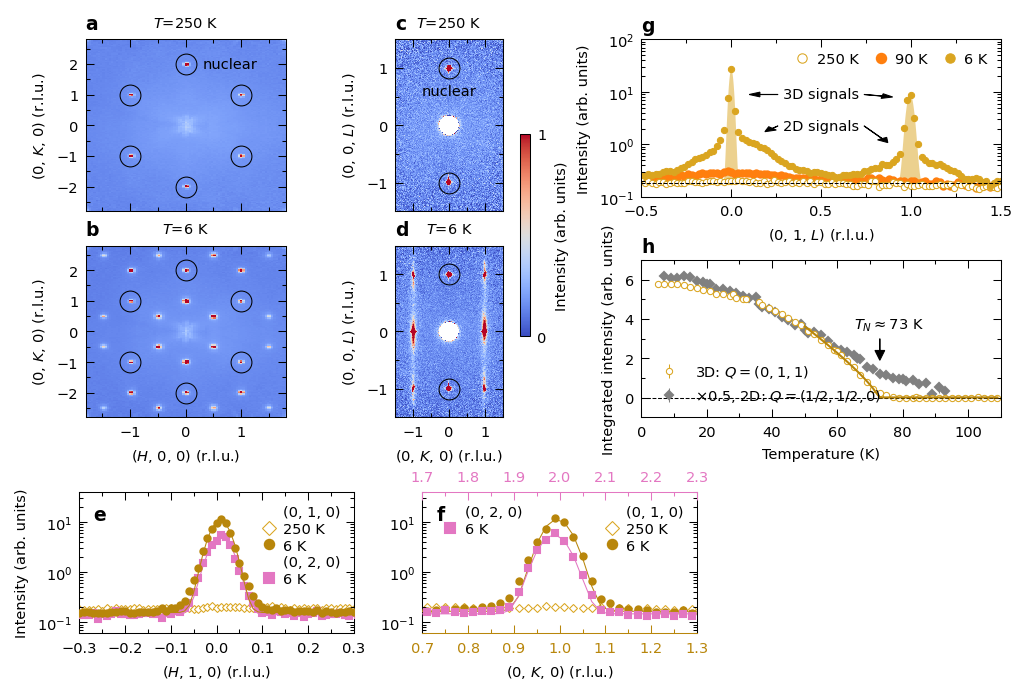

In [6]:
fig = plt.figure(figsize=(6.75,6.75/1.5), dpi=150)
gs1 = fig.add_gridspec(nrows=2, ncols=1, left=0.05, right=0.30, top=0.96, bottom=0.40, wspace=0, hspace=0.2)
gs2 = fig.add_gridspec(nrows=2, ncols=1, left=0.37, right=0.50, top=0.96, bottom=0.40, wspace=0, hspace=0.2)
gs3 = fig.add_gridspec(nrows=1, ncols=2, left=0.07, right=0.68, top=0.29, bottom=0.08, wspace=0.25, hspace=0)
gs4 = fig.add_gridspec(nrows=2, ncols=1, left=0.625, right=0.98, top=0.96, bottom=0.40, wspace=0, hspace=0.4)
axs1 = [fig.add_subplot(gs) for gs in gs1]
axs2 = [fig.add_subplot(gs) for gs in gs2]
axs3 = [fig.add_subplot(gs) for gs in gs3]
axs4 = [fig.add_subplot(gs) for gs in gs4]
cax = fig.add_axes([0.505, 0.52, 0.01, 0.3])
cmap = 'coolwarm'

# HK0 plane
plot_HK0_plane(axs1)

# 0KL plane
plot_0KL_plane(axs2, cax)

# Hcuts
plot_Hcuts(axs3[0], 'C6')

# Kcuts
plot_Kcuts(axs3[1], 'C6')

# L-dep
plot_Ldep(axs4[0], 'C1', T90=True)

# T-dep
plot_Tdep(axs4[1])

# fig.savefig('neutron.pdf')

# Spectral weights of 2D and 3D signals

In [7]:
# Ldep
## 250 K
alldata = dict(np.load('../corelli/HEPS3_HKL_250K.npz'))
dHKL = [0.02,0.04,1.]
HKL = [0.,1.,0.5]
chooseH = np.abs(alldata['Hrlu']-HKL[0])<=dHKL[0]
chooseK = np.abs(alldata['Krlu']-HKL[1])<=dHKL[1]
chooseL = np.abs(alldata['Lrlu']-HKL[2])<=dHKL[2]
x = alldata['Lrlu'][chooseL]
y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2))
cut1 = dict(x=x, y=y)
choose = np.logical_and(x>=-0.5, y<=1.5)
bg = np.mean(y[choose])
## 90 K
alldata = dict(np.load('../corelli/HEPS3_HKL_090K.npz'))
x = alldata['Lrlu'][chooseL]
y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2))
cut2 = dict(x=x, y=y)
## 6 K
alldata = dict(np.load('../corelli/HEPS3_HKL_006K.npz'))
x = alldata['Lrlu'][chooseL]
y = alldata['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2))
cut3 = dict(x=x, y=y)
### fit L=0
model = lmfit.models.GaussianModel()
params = model.make_params()
params['sigma'].set(value=0.01, min=1e-5, max=0.1)
params['amplitude'].set(value=100., min=1e-3, max=1e5)
params['center'].set(value=0., min=-0.02, max=0.02)
choose = np.logical_and(x>=-0.022, x<=0.022)
result = model.fit(y[choose]-bg, x=x[choose], params=params)
x_fit = np.arange(-0.1,0.1001,0.001)
y_fit = model.eval(params=result.params, x=x_fit)
fit_31 = dict(x=x_fit, y=y_fit, I=result.params['amplitude'].value)
### fit L=1
params['center'].set(value=1., min=1-0.02, max=1.02)
choose = np.logical_and(x>=1-0.022, x<=1.022)
result = model.fit(y[choose]-bg, x=x[choose], params=params)
x_fit = np.arange(1-0.1,1.1001,0.001)
y_fit = model.eval(params=result.params, x=x_fit)
fit_32 = dict(x=x_fit, y=y_fit, I=result.params['amplitude'].value)

choose = np.logical_and(cut3['x']>=-0.5, cut3['x']<=0.5)
I_all = np.trapz(cut3['y'][choose] - cut1['y'][choose], x=cut3['x'][choose])
I_3D = fit_31['I']
print(I_all, I_3D, I_all-I_3D, I_3D/I_all, np.sqrt(1.51**2/I_3D*I_all))

choose = np.logical_and(cut3['x']>=0.5, cut3['x']<=1.5)
I_all = np.trapz(cut3['y'][choose] - cut1['y'][choose], x=cut3['x'][choose])
I_3D = fit_32['I']
print(I_all, I_3D, I_all-I_3D, np.sqrt(1.51**2/I_3D*I_all))

1.1441252971763136 0.7632640534489641 0.38086124372734953 0.6671157917167725 1.8487421233494938
0.5610006348374618 0.41140706266579824 0.14959357217166352 1.7632859707689286


# Refinement

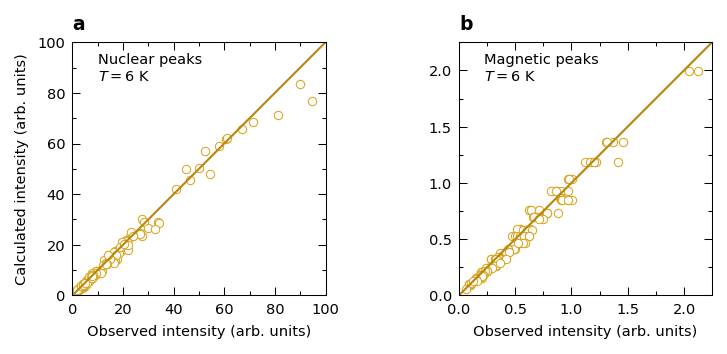

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(6.75,6.75/3), dpi=150, gridspec_kw=dict(top=0.9, bottom=0.15, left=0.2, right=0.9))

ax = axs[0]
data = np.loadtxt('../corelli/nucl_006K_0KL_datared.dat')
ax.plot(data[:,1]/1e2, data[:,2]/1e2, 'o', ms=4, color='goldenrod', mew=0.5, mfc='w', zorder=0)
ax.plot([0.,100.], [0.,100.], '-', lw=1, color='darkgoldenrod')
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0.,101,20.))
ax.set_yticks(np.arange(0.,101,20.))
ax.set_ylim(0, 100)
ax.set_ylabel('Calculated intensity (arb. units)')
ax.text(0.1, 0.85, 'Nuclear peaks\n$T=6$ K', color='k', transform=ax.transAxes)
plot_label(ax, 'a', x=0, y=1.05)

ax = axs[1]
data = np.loadtxt('../corelli/mag_006K_0KL.dat')
ax.plot(data[:,1]/1e2, data[:,2]/1e2, 'o', ms=4, color='goldenrod', mew=0.5, mfc='w', zorder=0)
ax.plot([0.,2.25], [0.,2.25], '-', lw=1, color='darkgoldenrod')
ax.set_xlim(0, 2.25)
ax.set_xticks(np.arange(0.,2.25,0.5))
ax.set_ylim(0, 2.25)
ax.set_yticks(np.arange(0.,2.25,0.5))
ax.text(0.1, 0.85, 'Magnetic peaks\n$T=6$ K', color='k', transform=ax.transAxes)
plot_label(ax, 'b', x=0, y=1.05)

for ax in axs:
    make_theme(ax, ticklength=4)
    ax.set_xlabel('Observed intensity (arb. units)')
    ax.set_aspect('equal')

# fig.savefig('neutron_fit.pdf')